In [1]:
# imports Libraries
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import FEATURED_DATA_PATH, MODELS_DIR, FIGURES_DIR
from src.inference import predict_churn_probability, add_risk_tiers

In [2]:
# load data and model
df = pd.read_csv(FEATURED_DATA_PATH)
model = joblib.load(MODELS_DIR / "churn_model.joblib")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,ChurnFlag,tenure_group,avg_monthly_value,num_services,has_protection,contract_risk,is_electronic_check,is_new_customer,is_high_value
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,0,0-12,14.925000,1,0,2,1,1,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,0,24-48,53.985714,3,1,1,0,0,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Yes,1,0-12,36.050000,3,1,2,0,1,0
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,0,24-48,40.016304,3,1,1,0,0,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Yes,1,0-12,50.550000,1,0,2,1,1,1


In [3]:
# prepare scoring dataset
X = df.drop(columns=["Churn", "ChurnFlag", "customerID"])

In [4]:
# predict churn probability
scored_df = predict_churn_probability(model, X)
scored_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,tenure_group,avg_monthly_value,num_services,has_protection,contract_risk,is_electronic_check,is_new_customer,is_high_value,churn_probability,predicted_churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,0-12,14.925000,1,0,2,1,1,0,0.645495,1
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,24-48,53.985714,3,1,1,0,0,0,0.039110,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,0-12,36.050000,3,1,2,0,1,0,0.317663,0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,24-48,40.016304,3,1,1,0,0,0,0.035335,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,0-12,50.550000,1,0,2,1,1,1,0.715249,1


In [5]:
# reattach identifiers and business fields
scored_df["customerID"] = df["customerID"].values
scored_df["Churn"] = df["Churn"].values
scored_df["MonthlyCharges"] = df["MonthlyCharges"].values
scored_df["TotalCharges"] = df["TotalCharges"].values
scored_df["tenure"] = df["tenure"].values
scored_df["Contract"] = df["Contract"].values
scored_df["PaymentMethod"] = df["PaymentMethod"].values

In [6]:
# assign risk tiers
scored_df = add_risk_tiers(scored_df)
scored_df[["customerID", "churn_probability", "risk_tier"]].head()

,customerID,churn_probability,risk_tier
0,7590-VHVEG,0.645495,Medium
1,5575-GNVDE,0.039110,Low
2,3668-QPYBK,0.317663,Low
3,7795-CFOCW,0.035335,Low
4,9237-HQITU,0.715249,Medium


Risk Tier Analysis

In [7]:
# Count customers by risk tier
scored_df["risk_tier"].value_counts()

risk_tier
Low       5563
Medium    1088
High       392
Name: count, dtype: int64

In [8]:
# percentage by risk tier
scored_df["risk_tier"].value_counts(normalize=True) * 100

risk_tier
Low       78.986227
Medium    15.447963
High       5.565810
Name: proportion, dtype: float64

In [9]:
# actual churn rate within each tier
pd.crosstab(scored_df["risk_tier"], scored_df["Churn"], normalize="index") * 100

Churn,No,Yes
risk_tier,,
High,14.285714,85.714286
Low,84.396908,15.603092
Medium,38.878676,61.121324


Revenue at Risk

In [11]:
# estimate monthly revenue at risk by tier
revenue_risk_summary = scored_df.groupby("risk_tier")["MonthlyCharges"].sum().sort_values(ascending=False)
revenue_risk_summary

risk_tier
Low       337979.90
Medium     85828.95
High       32307.75
Name: MonthlyCharges, dtype: float64

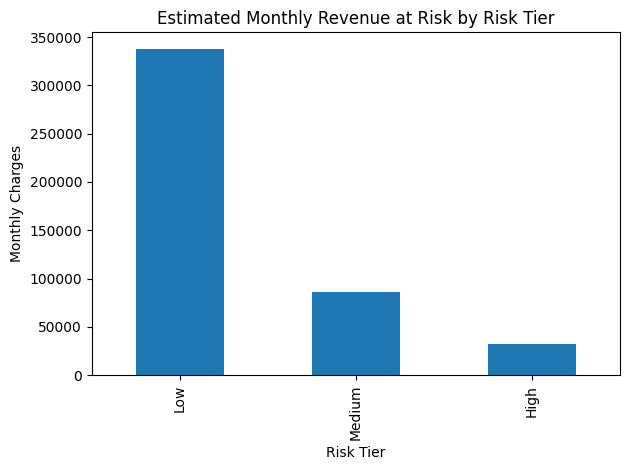

In [12]:
# visualize revenue at risk
plt.figure()
revenue_risk_summary.plot(kind="bar")
plt.title("Estimated Monthly Revenue at Risk by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "revenue_at_risk_by_tier.png")
plt.show()

Prioritization Table

In [13]:
# top high-risk customers
top_risk_customers = scored_df.sort_values("churn_probability", ascending=False)[
    ["customerID", "churn_probability", "risk_tier", "MonthlyCharges", "tenure", "Contract", "PaymentMethod"]
].head(20)

top_risk_customers

,customerID,churn_probability,risk_tier,MonthlyCharges,tenure,Contract,PaymentMethod
3380,5178-LMXOP,0.946828,High,95.10,1,Month-to-month,Electronic check
2208,7216-EWTRS,0.945784,High,100.80,1,Month-to-month,Electronic check
1976,9497-QCMMS,0.945332,High,93.55,1,Month-to-month,Electronic check
4800,9300-AGZNL,0.945028,High,94.00,1,Month-to-month,Electronic check
6866,0295-PPHDO,0.935599,High,95.45,1,Month-to-month,Electronic check
6482,5419-JPRRN,0.935491,High,101.45,1,Month-to-month,Electronic check
3209,8149-RSOUN,0.935488,High,93.85,1,Month-to-month,Electronic check
2577,4910-GMJOT,0.934897,High,94.60,1,Month-to-month,Electronic check
1410,7024-OHCCK,0.924074,High,93.85,2,Month-to-month,Electronic check
6240,6521-YYTYI,0.923716,High,93.30,1,Month-to-month,Electronic check


In [14]:
# define assumptions
INTERVENTION_COST = 20
RETENTION_SUCCESS_RATE = 0.25
RETENTION_VALUE_MONTHS = 3

In [15]:
# isolate high-risk customers
high_risk_df = scored_df[scored_df["risk_tier"] == "High"].copy()
high_risk_df.shape

(392, 32)

In [16]:
# estimate campaign size and cost
num_target_customers = len(high_risk_df)
campaign_cost = num_target_customers * INTERVENTION_COST

num_target_customers, campaign_cost

(392, 7840)

In [17]:
# estimate retained customers
estimated_retained_customers = int(num_target_customers * RETENTION_SUCCESS_RATE)
estimated_retained_customers

98

In [18]:
# estimate retained revenue
average_monthly_charge = high_risk_df["MonthlyCharges"].mean()

estimated_retained_revenue = (
    estimated_retained_customers *
    average_monthly_charge *
    RETENTION_VALUE_MONTHS
)

estimated_retained_revenue

np.float64(24230.8125)

In [19]:
# estimate ROI
roi = (estimated_retained_revenue - campaign_cost) / campaign_cost
roi

np.float64(2.0906648596938777)

In [20]:
# expected retained revenue using actual monthly charges
high_risk_df["expected_retained_revenue"] = (
    high_risk_df["MonthlyCharges"] *
    RETENTION_VALUE_MONTHS *
    RETENTION_SUCCESS_RATE
)

total_expected_retained_revenue = high_risk_df["expected_retained_revenue"].sum()
total_expected_retained_revenue

np.float64(24230.8125)

In [21]:
# net benefit
net_benefit = total_expected_retained_revenue - campaign_cost
net_benefit

np.float64(16390.8125)

In [22]:
# ROI using weighted revenue
weighted_roi = net_benefit / campaign_cost
weighted_roi

np.float64(2.0906648596938777)

In [24]:
# high-risk customers by contract
high_risk_df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    100.0
Name: proportion, dtype: float64

In [25]:
# high-risk customers by payment method
high_risk_df["PaymentMethod"].value_counts(normalize=True) * 100

PaymentMethod
Electronic check             86.224490
Mailed check                  8.163265
Bank transfer (automatic)     4.081633
Credit card (automatic)       1.530612
Name: proportion, dtype: float64

In [26]:
# high-risk customers by tenure band if available
if "tenure_group" in high_risk_df.columns:
    print(high_risk_df["tenure_group"].value_counts(normalize=True) * 100)

tenure_group
0-12     99.234694
12-24     0.765306
Name: proportion, dtype: float64


In [27]:
# high-risk and high-value customers
priority_df = high_risk_df.sort_values(
    ["MonthlyCharges", "churn_probability"],
    ascending=False
)[["customerID", "churn_probability", "MonthlyCharges", "tenure", "Contract", "PaymentMethod"]]

priority_df.head(20)

,customerID,churn_probability,MonthlyCharges,tenure,Contract,PaymentMethod
1719,2081-VEYEH,0.752947,107.95,3,Month-to-month,Electronic check
6894,1400-MMYXY,0.861675,105.90,3,Month-to-month,Electronic check
4826,3389-YGYAI,0.801140,105.50,8,Month-to-month,Electronic check
3085,5052-PNLOS,0.796096,105.35,3,Month-to-month,Bank transfer (automatic)
3956,4587-VVTOX,0.852056,105.30,6,Month-to-month,Electronic check
5933,6496-SLWHQ,0.888217,105.00,3,Month-to-month,Electronic check
171,1875-QIVME,0.839887,104.40,2,Month-to-month,Electronic check
2246,7181-BQYBV,0.909173,102.45,1,Month-to-month,Electronic check
6365,8884-ADFVN,0.837822,101.95,7,Month-to-month,Electronic check
6385,0702-PGIBZ,0.835617,101.70,4,Month-to-month,Electronic check


## Retention Campaign Assumptions

The business simulation is based on the following assumptions:

- Only high-risk customers are targeted
- Intervention cost per customer = $20
- Retention success rate = 25%
- Retained customer value = 3 months of monthly revenue

These assumptions are illustrative and are intended to show how predictive outputs can support retention planning and ROI estimation.

## Business Interpretation

The simulation shows that churn predictions can be translated into practical retention actions.

Key findings:
- High-risk customers represent the most urgent retention segment
- A targeted intervention strategy can help prioritize limited retention budgets
- Revenue-at-risk analysis shows that not all churners are equally valuable
- Combining churn probability with customer value enables smarter prioritization

This approach moves beyond prediction and supports business decision-making.

## Recommended Retention Actions

Based on the simulation, the business should prioritize:

1. High-risk, high-value customers for proactive retention campaigns
2. Month-to-month customers with short tenure for onboarding support
3. Customers without security/support bundles for cross-sell retention offers
4. Electronic check users for payment experience review and friction reduction

This supports a more targeted and cost-effective retention strategy.